# Lab 1: Introduction to OpenCV

The goal of this first lab is to present a small introduction to image processing using OpenCV. In each section, you can find:
* a small example - analyse the code and try it
* some exercises

In [ ]:
# Requirements for this tutorial
! pip install opencv-python
! pip install numpy
! pip install matplotlib

In [ ]:
# If you prefer, you can convert this notebook to a Python script by uncommenting the following command
! pip install nbconvert
! jupyter nbconvert --to script 01-introduction.ipynb

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

dataDir = 'images'

A reference table with some useful functions:

| Function | Description |
| ------------- | ------------- |
| **Low-level NumPy** | |
| `x = np.array(list)` | Converts Python list to `ndarray` |
| `x = np.zeros((80, 80, 3))` | Create an array 80x80x3 of zeros (i.e., a black image). |
| `x = np.ones((80, 80, 3))` | Same with ones. |
| `x = np.random.rand((80, 80, 3))` | Same but each value is a uniform sample from [0,1]. |
| `x = np.random.randn((80, 80, 3))` | Same but each value is a Gaussian sample from N(0,1). |
| `print(x.shape)` | Print the shape of the `ndarray`. |
| **Arithmetic** | |
| `x[:, :, 0]` | Access the first slice of the third-axis (i.e., if `x` is an image with format BGR, this would be the blue channel. |
| `x += 50` | Adds 50 to all pixels. |
| `x[:, :, 1] *= 0.5` | Divides the green channel by 2. |
| **OpenCV2 basic functions** | |
| `img = cv2.imread(filename)` | Opens the image from the disk given by filename as a `ndarray`. |
| `cv2.imwrite(filename, img)` | Save the given image in the disk with the given filename. |
| `cv2.imshow(window_name, img)` | Open the given image in a window. |
| `cv2.destroyWindow(window_name)` | Destroys the window. |
| **OpenCV2 color conversion** | |
| `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` | Converts the color format. |
| `cv2.cvtColor(img, cv2.COLOR_BGR2HSV)` | |
| `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` | |
| **OpenCV2 user interaction** | |
| `cv2.setMouseCallback(window_name, callback)` | Calls the given callback function whenver user interacts with the window. |
| `cv2.selectROI(window_name, img)` | Asks the user to select a part of the image and returns that. |
| `key = cv2.waitKey(0)` | Waits until the user presses a key. |
| `key = cv2.waitKey(delay)` | Wait until the user presses a key or a certain delay passes (in seconds). |

### Intro: How to read, write and display images using opencv

Download the folder named "Images for the exercises" from moodle. It contains examples of images that will be used in the various practical classes.

In [ ]:
# Opening an image
img = cv2.imread(os.path.join(dataDir, 'apple.jpg'))

# Showing the image
cv2.imshow("apple.jpg", img)

# Waiting for user to press a key to close the image
cv2.waitKey(0)

# Close the window after user pressed a key
cv2.destroyWindow("apple.jpg")

In [ ]:
# Check image characteristics
print(f"type: {type(img)}")
print(f"dtype: {img.dtype}")

# Check image size
h, w, c = img.shape
print(f'height: {h}')
print(f'width: {w}')
print(f'channels: {c}')

In [ ]:
# Saving image in bmp format
cv2.imwrite('new_apple.bmp', img)

### 1. Images – representation, grayscale and color, color spaces

In [ ]:
# Create an image
img = np.ones((100, 200, 1), np.uint8)

# Change the intensity to 100
img = img * 100

# Display the image
plt.imshow(img, cmap='gray', vmin=0, vmax=255) # when displaying grayscale images, use cmap="gray" and define the range of values [vmin, vmax]
plt.axis("off")

cv2.imshow("grayscale example", img)
cv2.waitKey(0)
cv2.destroyWindow("grayscale example")

In [ ]:
# Draw a line with thickness of 5 px
cv2.line(img, (0, 0), (200, 100), 255, 5)
cv2.line(img, (200, 0), (0, 100), 255, 5)

# Display image
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis("off")

# Display image using opencv
cv2.imshow("grayscale example", img)
cv2.waitKey(0)
cv2.destroyWindow("grayscale example")

Exercise 1.1 - Create a color image with 400 (rows) x 300 (columns) pixels in yellow. Then, draw two diagonal lines across the image, such that one is red, and the other one blue.

In [ ]:
img = np.zeros((400, 300, 3), dtype=np.uint8)
img[:] = [0, 255, 255] # Em BGR, amarelo é 255 de verde e 255 de vermelho

# X = Coluna | Y = Linha
cv2.line(img, (0, 0), (300, 400), (0, 0, 255), 5)
cv2.line(img, (300, 0), (0, 400), (255, 0, 0), 5)

# Display image using matplotlib
plt.imshow(img) # when displaying colored images, we do not need to define cmap="gray"
plt.axis("off")

# Display image using opencv
cv2.imshow("yellow image example", img)
cv2.waitKey(0)
cv2.destroyWindow("yellow image example")

The results displayed by matplotlib and opencv are different since openCV interprets images in the BGR color space, while matplotlib interprets the image in the RGB color space.

Exercise 1.2 - Convert the image from BGR to RGB so that the image appears yellow on matplotlib.

In [ ]:
altered_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image using matplotlib
plt.imshow(altered_img)
ax = plt.axis("off")

Exercise 1.3 - Read any color image, in BGR format, display it in one window, convert it to grayscale, display the grayscale image in another window and save the grayscale image to a different file.

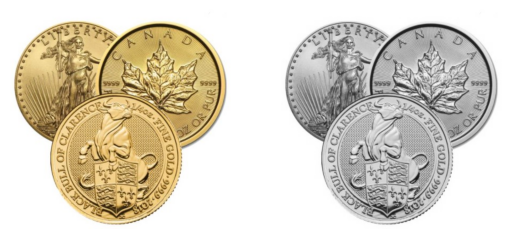

In [6]:
# Open image
bgr_img = cv2.imread(os.path.join(dataDir, 'coins_02.jpg'))

# Convert image into grayscale and show it in a different window
grayscale_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

# Display two images in two separate windows using opencv
cv2.imshow("Colored Window", bgr_img)
cv2.imshow("Grayscale Window", grayscale_img)

# Display two images side by side using matplotlib (remember that matplotlib uses the RGB color space instead of BGR)
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(rgb_img)
axarr[1].imshow(grayscale_img, cmap="gray", vmin=0, vmax=255)
axarr[0].axis("off")
axarr[1].axis("off")

# Save grayscale image
cv2.imwrite(os.path.join(dataDir, 'FEUP_01_gray.jpg'), grayscale_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

Exercise 1.4 - Split the 3 RGB channels and show each channel in a separate window. Add a constant value to one of the channels, merge the channels into a new color image and show the resulting image.

In [10]:
(B, G, R) = cv2.split(bgr_img)

cv2.imshow("Red", R)
cv2.imshow("Green", G)
cv2.imshow("Blue", B)

NEW_R = cv2.add(R, 100)

merged_img = cv2.merge([B, G, NEW_R])

cv2.imshow("Merged Image", merged_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

Exercise 1.5 - Convert the image to HSV, split the 3 HSV channels and show each channel in a separate window. Add a constant value to the saturation channel, merge the channels into a new color image and show the resulting image.

In [11]:
hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
(H, S, V) = cv2.split(hsv_img)

cv2.imshow("Hue", H)
cv2.imshow("Saturation", S)
cv2.imshow("Value", V)

NEW_S = cv2.add(S, 100)

merged_hsv = cv2.merge([H, NEW_S, V])
final_img = cv2.cvtColor(merged_hsv, cv2.COLOR_HSV2BGR) # É necessário converter novamente para BGR, porque é o formato que o OpenCV está à espera

cv2.imshow("Merged Image - More Saturation", final_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

### 2. OpenCV Interactive Interface

Exercise 2.1 - Open an image on a new window. When the user moves the mouse, print the coordinates and BGR component of the pixel under the cursor. When the user clicks on a pixel, modify that pixel to blue.

In [ ]:
img_path = os.path.join(dataDir, 'giraffe.jpg')
img = cv2.imread(img_path)

# Função Callback
def mouse_event_handler(event, x, y, flags, param):
    global img 
    
    # Quando o rato se move
    if event == cv2.EVENT_MOUSEMOVE:
        # X = Coluna | Y = Linha
        # No NumPy é ao contrário (img[row/y, col/x]) para aceder diretamente à matriz da imagem
        bgr_pixel = img[y, x]
        print(f"Coordenadas: ({x}, {y}) | BGR: {bgr_pixel}", end='\r')

    # Quando o utilizador clica
    if event == cv2.EVENT_LBUTTONDOWN:
        # Azul em BGR é [255, 0, 0]
        img[y, x] = [255, 0, 0]
        cv2.imshow("Interact Window", img)

cv2.namedWindow("Interact Window")
cv2.setMouseCallback("Interact Window", mouse_event_handler)

while True:
    cv2.imshow("Interact Window", img)
    
    # Sair se pressionar 'q' ou ESC
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == 27:
        break

cv2.destroyAllWindows()

Exercise 2.2 - Allow the user to select a region of interest (ROI) in the image, by clicking on two points that identify two opposite corners of the selected ROI, and save the ROI into another file.

In [ ]:
img_path = os.path.join(dataDir, 'giraffe.jpg')
img = cv2.imread(img_path)

roi_info = cv2.selectROI("ROI", img, fromCenter=False, showCrosshair=True)

x, y, w, h = roi_info

# Imagem recortada vai ser: [START_ROW : END_ROW; START_COL : END_COL]
roi_img = img[y : y+h, x : x+w]

cv2.imshow("ROI in the Image", roi_img)
cv2.imwrite(os.path.join(dataDir, 'roi_giraffe.jpg'), roi_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

### 3. Video – acquisition and simple processing

In [ ]:
# Define a VideoCapture Object
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

frame_nr = 0
while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # If frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Display the resulting frame
    cv2.imshow('webcam', frame)

    # Wait for user to press s to save frame
    if cv2.waitKey(1) == ord('s'):
        frame_name = 'frame' + str(frame_nr) + '.png'
        cv2.imwrite(frame_name, frame)
        cv2.imshow("Saved frame: " + frame_name, frame)
        cv2.waitKey(0)
        cv2.destroyWindow("Saved frame: " + frame_name)

    # Wait for user to press q to quit
    if cv2.waitKey(1) == ord('q'):
        break

    frame_nr += 1

# When everything is done, release the capture
cap.release()
cv2.destroyAllWindows()

Exercise 3.1 - Using the previous example as the baseline, implement a script that acquires the video from the webcam, converts it to grayscale, and shows the frames in binary format (i.e. the intensity of each pixel is 0 or 255); use a threshold value of 128.

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # If frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Apply Binary Thresholding (If pixel intensity > 128, set to 255 (white). Else, set to 0 (black))
    # The '_' ignores the first return value (the threshold used)
    _, binary_frame = cv2.threshold(gray_frame, 128, 255, cv2.THRESH_BINARY)

    cv2.imshow('Binary Webcam Feed', binary_frame)

    key = cv2.waitKey(1) & 0xFF

    # Press 's' to save the current binary frame
    if key == ord('s'):
        cv2.imwrite('binary_capture.png', binary_frame)

    # Press 'q' to quit the application
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Exercise 3.2 - Implement a simple detection/tracking algorithm for colored objects, using the following steps:
1. take each frame of the video;
2. convert from BGR to HSV color-space;
3. threshold the HSV image for a range of color values (creating a binary mask);
4. erase everything in the original image except the mask.

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Hue range is [0,179], Saturation [0,255], Value [0,255]
lower_blue = np.array([20, 100, 100])
upper_blue = np.array([30, 255, 255])

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv_img = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # This creates a mask where a certain color pixels are 255 (white) and others are 0 (black)
    mask = cv2.inRange(hsv_img, lower_blue, upper_blue)

    # This keeps the original colors only where the mask is white
    result = cv2.bitwise_and(frame, frame, mask=mask)

    cv2.imshow('Original Frame', frame)
    cv2.imshow('Mask', mask)
    cv2.imshow('Color Tracking Result', result)

    # Handle keyboard input
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()